In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical 

In [2]:
df=pd.read_csv("mnist_train.csv")
df_test=pd.read_csv("mnist_train.csv")

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [6]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [7]:
df.isnull().count()

label       42000
pixel0      42000
pixel1      42000
pixel2      42000
pixel3      42000
            ...  
pixel779    42000
pixel780    42000
pixel781    42000
pixel782    42000
pixel783    42000
Length: 785, dtype: int64

In [8]:
x_train=df.drop("label",axis=1).values
y_train=df["label"].values
x_test=df_test.drop("label",axis=1).values
y_test=df["label"].values

In [9]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

In [10]:
x_train_img=x_train.reshape(-1,28,28)
x_test_img=x_test.reshape(-1,28,28)

In [11]:
x_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [12]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

In [13]:
perceptron= Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation="softmax")
           ])            

In [14]:
perceptron.compile(optimizer="sgd",loss="categorical_crossentropy",metrics=["accuracy"])

In [15]:
history_perc=perceptron.fit(x_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(x_test_img,y_test_cat),verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7922 - loss: 0.8919 - val_accuracy: 0.8617 - val_loss: 0.5574
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8725 - loss: 0.4972 - val_accuracy: 0.8819 - val_loss: 0.4540
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8850 - loss: 0.4315 - val_accuracy: 0.8890 - val_loss: 0.4116
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8920 - loss: 0.3989 - val_accuracy: 0.8946 - val_loss: 0.3862
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8957 - loss: 0.3784 - val_accuracy: 0.8986 - val_loss: 0.3694


In [16]:
acc=perceptron.evaluate(x_test_img,y_test_cat,verbose=1)
print(acc)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8986 - loss: 0.3694
[0.36940333247184753, 0.8986428380012512]


In [17]:
#ANN
model_ann= Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
           ])            

In [18]:
model_ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [19]:
history_ann=model_ann.fit(x_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(x_test_img,y_test_cat),verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9191 - loss: 0.2795 - val_accuracy: 0.9623 - val_loss: 0.1274
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9653 - loss: 0.1146 - val_accuracy: 0.9772 - val_loss: 0.0757
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9759 - loss: 0.0775 - val_accuracy: 0.9853 - val_loss: 0.0488
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9824 - loss: 0.0574 - val_accuracy: 0.9843 - val_loss: 0.0480
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9861 - loss: 0.0443 - val_accuracy: 0.9896 - val_loss: 0.0327


In [20]:
acc=model_ann.evaluate(x_test_img,y_test_cat,verbose=1)
print(acc)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9896 - loss: 0.0327
[0.032730430364608765, 0.9896190762519836]


In [21]:
x_train_cnn=x_train.reshape(-1,28,28,1)
x_test_cnn=x_test.reshape(-1,28,28,1)

In [22]:
#CNN
model_cnn= Sequential([
    Conv2D(32, kernel_size=(3,3),activation="relu",input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3),activation="relu"),
    MaxPooling2D(pool_size=(2,2)),    
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])    

In [23]:
model_cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [24]:
history_cnn=model_cnn.fit(x_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_data=(x_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.9174 - loss: 0.2651 - val_accuracy: 0.9842 - val_loss: 0.0546
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 49s 37ms/step - accuracy: 0.9722 - loss: 0.0924 - val_accuracy: 0.9874 - val_loss: 0.0398
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 46s 35ms/step - accuracy: 0.9805 - loss: 0.0681 - val_accuracy: 0.9925 - val_loss: 0.0245
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 86s 38ms/step - accuracy: 0.9833 - loss: 0.0557 - val_accuracy: 0.9923 - val_loss: 0.0251
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 50s 38ms/step - accuracy: 0.9852 - loss: 0.0473 - val_accuracy: 0.9952 - val_loss: 0.0152


In [35]:
acc=model_cnn.evaluate(x_test_cnn,y_test_cat,verbose=1)
print(acc)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9952 - loss: 0.0152
[0.01522545050829649, 0.9952142834663391]


In [26]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

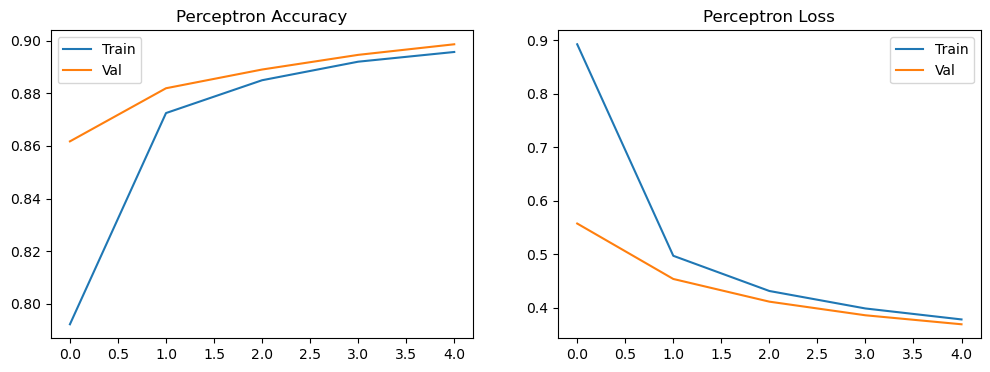

In [27]:
plot_training(history_perc, "Perceptron")

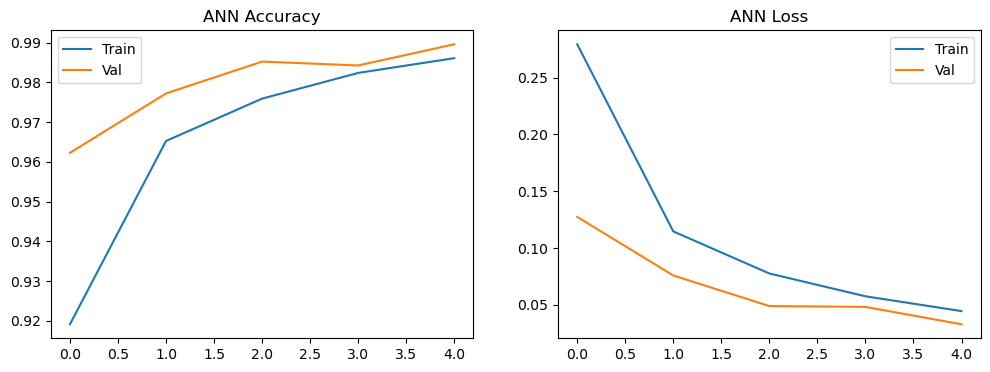

In [28]:

plot_training(history_ann, "ANN")

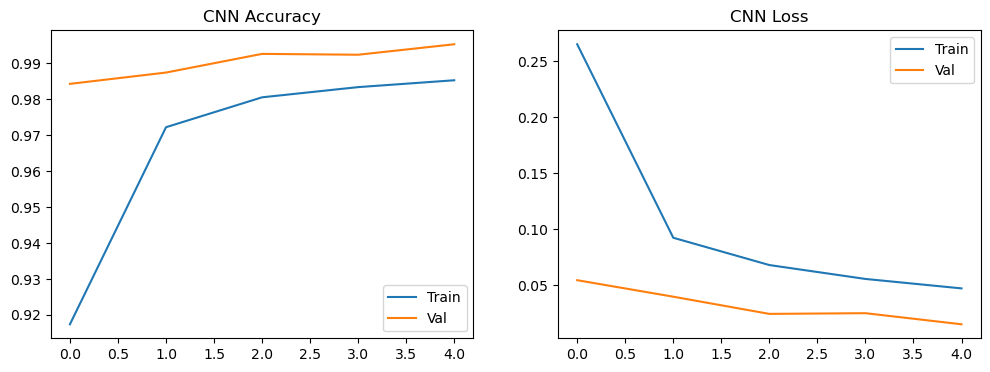

In [29]:
plot_training(history_cnn, "CNN")

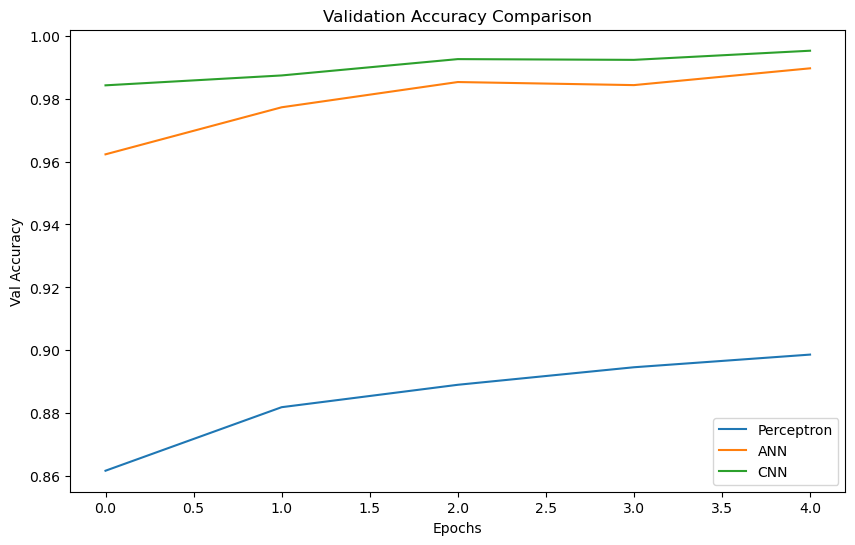

In [30]:
plt.figure(figsize=(10,6))
plt.plot(history_perc.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [31]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()
     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


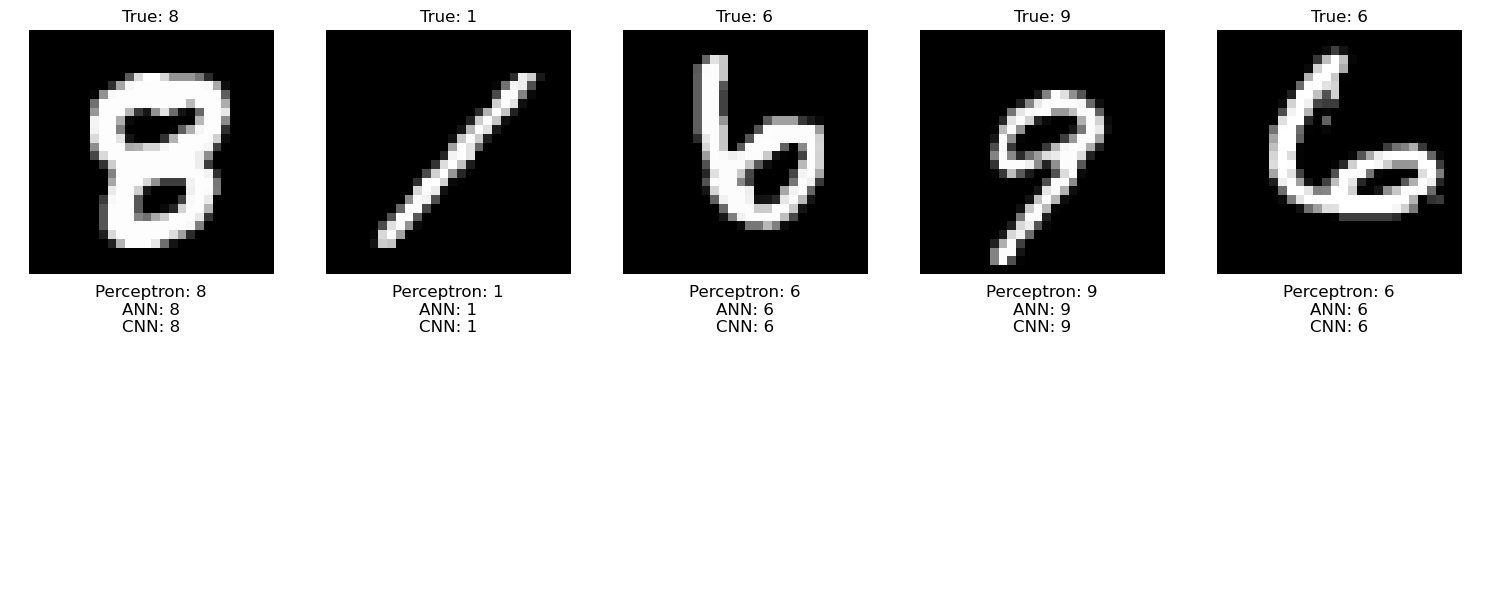

In [32]:
show_side_by_side([perceptron,model_ann, model_cnn], ["Perceptron", "ANN", "CNN"], x_test_img, x_test_cnn, y_test, 5)
     

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step


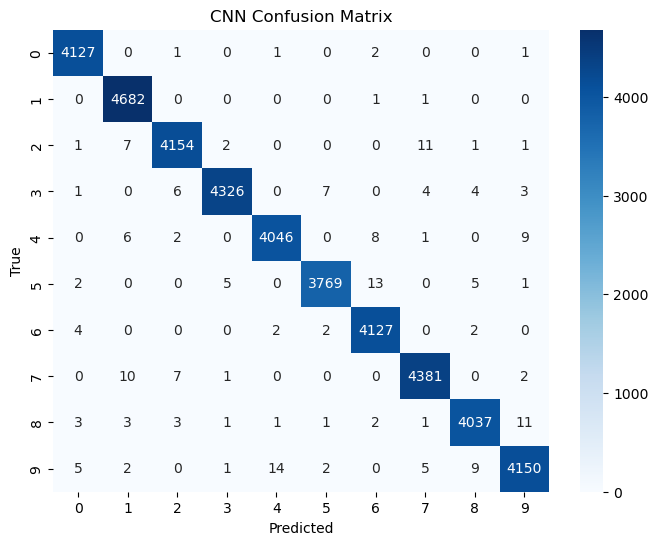

In [36]:
y_pred_cnn = np.argmax(model_cnn.predict(x_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [45]:
import joblib
joblib.dump(perceptron,"perceptron.pkl")

['perceptron.pkl']

In [46]:
model_ann.save("ANN.keras")

In [47]:
model_cnn.save("CNN.keras")

In [49]:
print("all three models are saved sucessfully!")

all three models are saved sucessfully!


In [50]:
print(x_test.shape)

(42000, 784)


In [51]:
print(x_test[0].shape)

(784,)


In [52]:
import os
print(os.getcwd())

C:\Users\ghans\CNN


In [54]:
os.listdir()

['.ipynb_checkpoints',
 'ANN.keras',
 'CNN.keras',
 'mnist_project.ipynb',
 'mnist_train.csv',
 'perceptron.pkl']

In [56]:
import streamlit as st

In [57]:
st.write("Perceptron:", perceptron.n_features_in_)
st.write("ANN:", ann.input_shape)
st.write("CNN:", cnn.input_shape)

AttributeError: 'Sequential' object has no attribute 'n_features_in_'